#<h1><center>Lab 1 - A1</center></h1>

## Knapsack Problem
- $n$ objects, each has a value ($v$) and a weight ($w$)
- Objective: the knapsack to contain max value without exceeding max weight $W$
 - $x_i=1$ means object $i$ is selected
 - $x_i=0$ means object $j$ is not selected

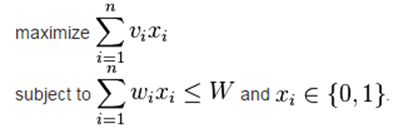


## WORK DURING THE LAB
1.	Exhaustive search: generate all possible binary strings of size N and print them on the screen. Test the code for different values of N.
2.	Read data for the knapsack problem.
3.	Generate a random solution for the knapsack problem and verify its quality.

**Points for the work during the lab: 25p**


##	REQUIREMENTS
1.	Source code (notebook) needs to be documented.
2.	Algorithms have to be tested for several parameter values (sufficient to clearly determine performance).
3.	Experiments must be performed for all available problem instances and results compared for different parameter settings.
4.	Results of the experiments need to be saved in output files, indicating solution quality, parameter values used, number of runs.
5.	A report should capture the following: problem definition, algorithm used (name, steps/pseudocode), parameter setting, comparative results of experiments, discussion of results.


In [19]:
def load_data(file_name: str) -> "list[tuple[int, int]]":
    """
    Loads the knapsack items from a file.

    The file format is:
    - first line: number of items (n)
    - next n lines: item_id weight value
    - last line: capacity (handled by load_capacity)

    Returns:
        list of tuples (weight, value) for each item
    """
    weights_and_values = []
    with open(file_name) as f:
        lines = [line.strip() for line in f if line.strip()]

    n = int(lines[0])

    for i in range(1, n + 1):
        parts = lines[i].split()
        weight = int(parts[1])
        value = int(parts[2])
        weights_and_values.append((weight, value))

    return weights_and_values

In [14]:
def load_capacity(file_name: str) -> int:
    """
    Reads the knapsack capacity from the file.

    The capacity is stored in the last line of the instance file.
    """
    with open(file_name, "r") as f:
        lines = [line.strip() for line in f if line.strip()]
    return int(lines[-1])

In [15]:
import numpy as np

def generate_solution(n: int):
    """
        Generate solution of length n using binary encoding
        Input:
          n: int
        Output:
          sol: list
              - binary encoding solution
    """
    return list(map(int, np.random.randint(2, size=n)))


def total_weight(items: list, sol: list):
    """
        Total weight function
        Input:
          items: list
          sol: list
              - binary encoding solution
        Output:
          s: int
    """
    s = 0
    for i, (w,v) in enumerate(items):
        s += w * sol[i]
    return s

def total_value(items: list, sol: list):
    """
        Total value function
        Input:
          items: list
          sol: list
              - binary encoding solution
        Output:
          s: int
    """
    s = 0
    for i, (w,v) in enumerate(items):
        s += v * sol[i]
    return s

def is_valid(items: list, sol: list, capacity: int):
    """
     A solution is valid if its sum is lower or equal than capacity
     Input:
       items: list
       sol: list
           - binary encoding solution
       capacity: int
     Output:
        bool
    """
    return total_weight(items, sol) <= capacity


def generate_valid_solution(n: int, items: list, capacity: int):
    """
     A solution is valid if its sum is lower than capacity
     Input:
       n: int
       items: list
       capacity: int
     Output:
        sol: list
    """
    stop = False
    sol = []
    while not stop:
        sol = generate_solution(n)
        stop = is_valid(items, sol, capacity)
    return sol

def generate_k_solutions(n: int, k: int, items: list, capacity: int):
    """
      Generate k valid solutions
      Input:
        n: int
        k: int
        items: list
        capacity: int
      Output:
        solution_list: list
            - list of valid solutions
    """
    solution_list = []
    while k > 0:
        sol = generate_valid_solution(n, items, capacity)
        solution_list.append(sol)
        k -= 1
    return solution_list

def random_search(k: int, items: list, capacity: int):
    """
      A random search algorithm
      Input:
        k: int
        items: list
        capacity: int
      Output:
        best: list
            - best solution
        solution_list: list
            - list of all solutions generated
    """
    solution_list = generate_k_solutions(len(items), k, items, capacity)
    best = max(solution_list, key=lambda x: total_value(items, x))
    return best, total_value(items, best), total_weight(items, best), solution_list

In [16]:
from matplotlib import pyplot as plt


def random_search_n_times(n: int, k: int, items: list, capacity: int):
    """
    Runs the random search algorithm n times and returns a list of the best solutions found.
    Input:
        n: int
            - number of times to run the algorithm
        k: int
            - number of solutions to generate in each run
        items: list
        capacity: int
    Output:
        best_solutions: list
    """
    best_solutions = []
    for _ in range(n):
        best_solution, best_val, best_w, _ = random_search(k, items, capacity)
        best_solutions.append((best_solution, best_val, best_w))
    return best_solutions


def plot_solutions(items: list, solution_list: "list[list]"):
    """
    Plots value and weight of the solutions in solution_list.
    Input:
        items: list
        solution_list: list
            - list of solutions
    Output:
        None
    """
    values = [total_value(items, sol) for sol in solution_list]
    weights = [total_weight(items,sol) for sol in solution_list]

    plt.plot(values, label="Value")
    plt.plot(weights, label="Weight")

    plt.xlabel("Iteration")
    plt.ylabel("Value / Weight")
    plt.title("Random Search Results")
    plt.legend()

    plt.show()

In [17]:
file_name = ["knapsack-20.txt", "knapsack-200.txt"]
# problem instance given by file

output_file = open("knapsack_results.txt", "w")
# output file used to store results
output_file.write("Instance,Runs,k,Best Value,Average Value\n")

# k - number of iterations
# runs - number of runs
k_values = [10, 50, 100]
runs_values = [10, 50, 100]

# running the algorithm for multiple sets of params and saving the results in a markdown table
markdown_table = "| Instance | Runs | k | Best Value | Average Value |\n"
markdown_table += "|-----------------|----|----|-----|-------| \n"

for files in file_name:
    items = load_data(files)
    capacity = load_capacity(files)

    for k in k_values:
        for runs in runs_values:
            best_results = random_search_n_times(runs, k, items, capacity)
            best = max(best_results, key=lambda x: x[1])
            average = sum([x[1] for x in best_results]) / len(best_results)

            # print("Best value", best[1])
            # print("Best solution", best[0])
            # print("Weight", best[2], "/", capacity)
            # print("Average value over runs:", average)

            markdown_table += f"| {files} | {runs} | {k} | {best[1]} | {average:.2f} |\n"

            # save results to file
            output_file.write(f"{files},{runs},{k},{best[1]},{average:.2f}\n")

output_file.close()
print(markdown_table)

| Instance | Runs | k | Best Value | Average Value |
|-----------------|----|----|-----|-------| 
| knapsack-20.txt | 10 | 10 | 672 | 595.50 |
| knapsack-20.txt | 50 | 10 | 691 | 597.44 |
| knapsack-20.txt | 100 | 10 | 753 | 599.79 |
| knapsack-20.txt | 10 | 50 | 697 | 653.10 |
| knapsack-20.txt | 50 | 50 | 716 | 654.36 |
| knapsack-20.txt | 100 | 50 | 766 | 658.27 |
| knapsack-20.txt | 10 | 100 | 689 | 657.00 |
| knapsack-20.txt | 50 | 100 | 723 | 671.22 |
| knapsack-20.txt | 100 | 100 | 755 | 674.01 |
| knapsack-200.txt | 10 | 10 | 96676 | 96183.30 |
| knapsack-200.txt | 50 | 10 | 97001 | 95738.76 |
| knapsack-200.txt | 100 | 10 | 97160 | 95908.41 |
| knapsack-200.txt | 10 | 50 | 97220 | 96574.60 |
| knapsack-200.txt | 50 | 50 | 97384 | 96568.52 |
| knapsack-200.txt | 100 | 50 | 97316 | 96535.47 |
| knapsack-200.txt | 10 | 100 | 97290 | 96763.90 |
| knapsack-200.txt | 50 | 100 | 97358 | 96725.72 |
| knapsack-200.txt | 100 | 100 | 97479 | 96733.11 |



   <h6>Problem definition</h6>
The Knapsack Problem consists of selecting a subset of items, each having a weight and a value, such that the total weight does not exceed a given capacity while the total value is maximized.

   <h6>Algorithm used</h6>
   Random Search for Knapsack

1. Generate a random binary solution.
2. Check if the solution satisfies the capacity constraint.
3. Compute the value of the solution.
4. Repeat the process k times.
5. Keep the best solution found.
6. Repeat the whole process for several runs.

   <h6>Parameter setting</h6>
k = number of candidate solutions generated in one run

runs = number of times the algorithm is executed

k ∈ {10, 50, 100}

runs ∈ {10, 50, 100}

   <h6>Comparative results of experiments</h6>
See markdown table.

   <h6>Discussion of results</h6>
Increasing the number of iterations generally improves the quality of the solutions, since more candidate solutions are explored. However, because Random Search generates solutions completely at random, the improvement is not strictly monotonic and the average solution value may fluctuate.

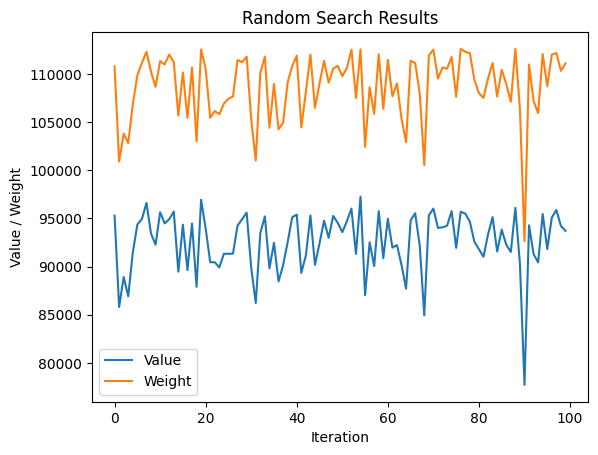

In [18]:
# we can showcase the evolution of a solution using a plot
_, _, _, solution_list = random_search(k, items, capacity)
plot_solutions(items, solution_list)